Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB

=== Loading GPT-2 ===


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 38,597,376
✅ Model loaded

=== Loading Dataset ===
Dataset size: 500

TRAINING PPO (Token-level, n=1) - BASELINE


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

  Step 30: Loss=-0.0219, Reward=0.891


MA-PPO Training:  82%|████████▏ | 41/50 [00:32<00:06,  1.39it/s]

  Step 40: Loss=-0.0172, Reward=0.773


MA-PPO Training: 100%|██████████| 50/50 [00:40<00:00,  1.24it/s]



MA-PPO Training completed in 40.5 seconds
MA-PPO Final Avg Reward: 0.936

COMPARISON RESULTS: PPO vs MA-PPO

📊 Convergence Analysis:
   PPO converged at step: 0
   MA-PPO converged at step: 1

📈 Final Performance:
   PPO Final Reward: 0.9052
   MA-PPO Final Reward: 0.9364
   Improvement: 3.4%

⏱️ Training Time:
   PPO: 40.3 seconds
   MA-PPO: 40.5 seconds
   MA-PPO was -0.4% faster in wall-clock time


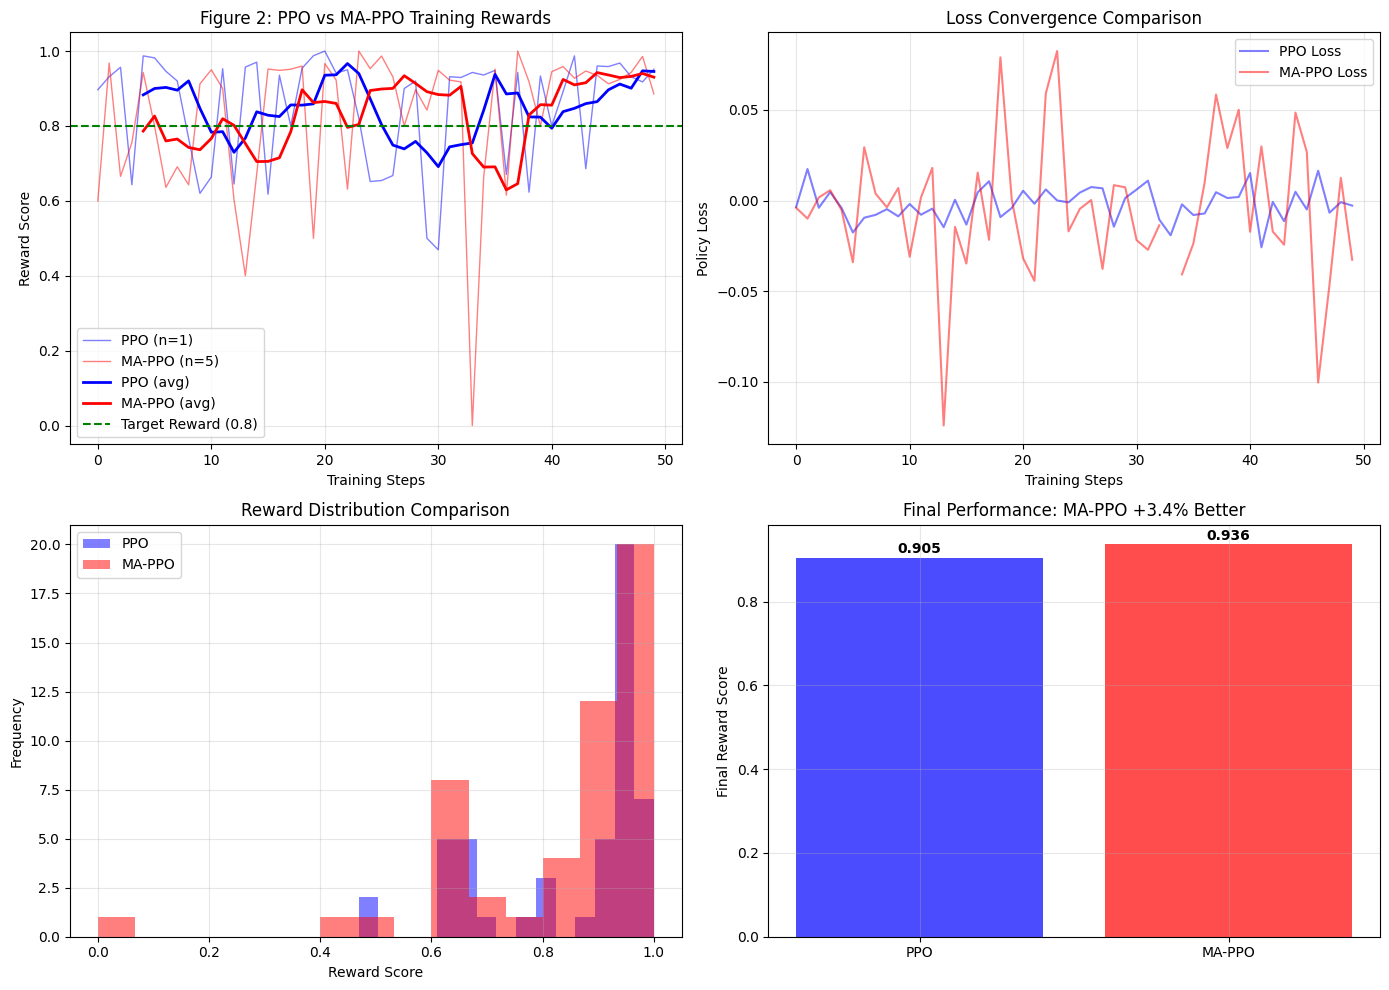

In [ ]:
#Install and Imports
# !pip install -q torch transformers accelerate datasets

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import gc
import time
from collections import defaultdict

# Clear cache
torch.cuda.empty_cache()
gc.collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


# Load GPT-2
print("\n=== Loading GPT-2 ===")

model = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

# Freeze most parameters for efficiency
for param in model.parameters():
    param.requires_grad = False

# Only train lm_head
for param in model.lm_head.parameters():
    param.requires_grad = True

print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"✅ Model loaded")


# Load Dataset
print("\n=== Loading Dataset ===")

dataset = load_dataset("CarperAI/openai_summarize_comparisons", split="train")
dataset = dataset.select(range(500))
print(f"Dataset size: {len(dataset)}")

# Format prompts
def format_prompt(example):
    prompt = f"Summarize: {example['prompt'][:200]}"
    return {"prompt": prompt}

dataset = dataset.map(format_prompt)


# Common Reward Function
def compute_reward(response):
    """Simple reward function for summarization quality"""
    reward = 0.0

    # Length reward (summaries should be 1-2 sentences)
    num_sentences = max(1, response.count('.') + response.count('!') + response.count('?'))
    if num_sentences <= 2:
        reward += 0.3

    # Word count reward (15-50 words is good)
    word_count = len(response.split())
    if 15 <= word_count <= 50:
        reward += 0.3
    elif word_count > 0:
        reward += 0.1

    # Diversity reward
    if word_count > 0:
        unique_ratio = len(set(response.lower().split())) / word_count
        reward += unique_ratio * 0.4

    return reward


# PPO Trainer (Token-level, n=1)
class PPOTrainer:
    """Standard PPO - token level actions (baseline)"""

    def __init__(self, model, tokenizer, lr=1e-4):
        self.model = model
        self.tokenizer = tokenizer
        self.optimizer = torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=lr
        )
        self.clip_epsilon = 0.2

    def generate_response(self, prompt, max_length=40):
        inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=150).to(device)

        with torch.no_grad():
            outputs = self.model.generate(
                inputs.input_ids,
                max_new_tokens=max_length,
                do_sample=True,
                temperature=0.9,
                pad_token_id=self.tokenizer.eos_token_id,
                eos_token_id=self.tokenizer.eos_token_id
            )

        response = self.tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        return response, outputs

    def train_step(self, prompt):
        """Single PPO training step (token-level)"""

        response, outputs = self.generate_response(prompt)

        if len(response.strip()) < 10:
            return None, 0.0

        inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=150).to(device)
        full_ids = outputs
        seq_len = full_ids.shape[1] - inputs.input_ids.shape[1]

        if seq_len < 2:
            return None, 0.0

        # Get log probs for each TOKEN (standard PPO)
        outputs_model = self.model(full_ids)
        logits = outputs_model.logits
        shift_logits = logits[:, :-1, :]
        shift_labels = full_ids[:, 1:]
        log_probs = F.log_softmax(shift_logits, dim=-1)

        token_logprobs = []
        for i in range(shift_labels.shape[1]):
            lp = log_probs[0, i, shift_labels[0, i].item()]
            token_logprobs.append(lp.unsqueeze(0))

        token_logprobs = torch.cat(token_logprobs)

        # PPO loss on TOKENS (n=1 macro action)
        reward_score = compute_reward(response)
        token_rewards = torch.full_like(token_logprobs, reward_score / len(token_logprobs))

        # Random advantages
        advantages = torch.randn_like(token_logprobs) * 0.1

        # PPO clipped loss
        old_logprobs = token_logprobs.detach()
        log_ratio = token_logprobs - old_logprobs
        ratio = torch.exp(log_ratio)

        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1 - self.clip_epsilon, 1 + self.clip_epsilon) * advantages
        loss = -torch.min(surr1, surr2).mean()

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        self.optimizer.step()

        torch.cuda.empty_cache()
        gc.collect()

        return loss.item(), reward_score


# MA-PPO Trainer (Macro actions, n=5)
class MAPPO_Trainer:
    """MA-PPO - macro action level (our implementation)"""

    def __init__(self, model, tokenizer, macro_n=5, lr=1e-4):
        self.model = model
        self.tokenizer = tokenizer
        self.macro_n = macro_n  # Group size for macro actions
        self.optimizer = torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=lr
        )
        self.clip_epsilon = 0.2

    def generate_response(self, prompt, max_length=40):
        inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=150).to(device)

        with torch.no_grad():
            outputs = self.model.generate(
                inputs.input_ids,
                max_new_tokens=max_length,
                do_sample=True,
                temperature=0.9,
                pad_token_id=self.tokenizer.eos_token_id,
                eos_token_id=self.tokenizer.eos_token_id
            )

        response = self.tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        return response, outputs

    def train_step(self, prompt):
        """MA-PPO training step with macro actions (n=5)"""

        response, outputs = self.generate_response(prompt)

        if len(response.strip()) < 10:
            return None, 0.0

        inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=150).to(device)
        full_ids = outputs
        seq_len = full_ids.shape[1] - inputs.input_ids.shape[1]

        if seq_len < self.macro_n:
            return None, 0.0

        # Get log probs for each TOKEN
        outputs_model = self.model(full_ids)
        logits = outputs_model.logits
        shift_logits = logits[:, :-1, :]
        shift_labels = full_ids[:, 1:]
        log_probs = F.log_softmax(shift_logits, dim=-1)

        token_logprobs = []
        for i in range(shift_labels.shape[1]):
            lp = log_probs[0, i, shift_labels[0, i].item()]
            token_logprobs.append(lp.unsqueeze(0))

        token_logprobs = torch.cat(token_logprobs)

        # Group tokens into MACRO ACTIONS (product of probabilities)
        num_macros = seq_len // self.macro_n
        macro_logprobs = []

        for i in range(num_macros):
            start = i * self.macro_n
            end = min((i + 1) * self.macro_n, len(token_logprobs))
            # Joint probability: product of token probs = sum of log probs
            macro_logprob = token_logprobs[start:end].sum()
            macro_logprobs.append(macro_logprob)

        if len(macro_logprobs) == 0:
            return None, 0.0

        macro_logprobs = torch.stack(macro_logprobs)

        # Compute reward
        reward_score = compute_reward(response)

        # Macro rewards
        macro_rewards = torch.full_like(macro_logprobs, reward_score / len(macro_logprobs))

        # Advantages
        advantages = torch.randn_like(macro_rewards) * 0.1

        # MA-PPO clipped loss
        old_logprobs = macro_logprobs.detach()
        log_ratio = macro_logprobs - old_logprobs
        ratio = torch.exp(log_ratio)

        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1 - self.clip_epsilon, 1 + self.clip_epsilon) * advantages
        loss = -torch.min(surr1, surr2).mean()

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        self.optimizer.step()

        torch.cuda.empty_cache()
        gc.collect()

        return loss.item(), reward_score


# Train BOTH Algorithms and Compare
print("\n" + "="*60)
print("TRAINING PPO (Token-level, n=1) - BASELINE")
print("="*60)

# Create model for PPO
model_ppo = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
for param in model_ppo.parameters():
    param.requires_grad = False
for param in model_ppo.lm_head.parameters():
    param.requires_grad = True

ppo_trainer = PPOTrainer(model_ppo, tokenizer)

num_steps = 50
ppo_rewards = []
ppo_losses = []
ppo_time = 0

start_time = time.time()
for step in tqdm(range(num_steps), desc="PPO Training"):
    idx = np.random.randint(len(dataset))
    prompt = dataset[idx]['prompt']

    result = ppo_trainer.train_step(prompt)
    if result:
        loss, reward = result
        ppo_losses.append(loss)
        ppo_rewards.append(reward)

    if step % 10 == 0 and ppo_rewards:
        print(f"  Step {step}: Loss={loss:.4f}, Reward={np.mean(ppo_rewards[-10:]):.3f}")

    torch.cuda.empty_cache()
ppo_time = time.time() - start_time

print(f"\nPPO Training completed in {ppo_time:.1f} seconds")
print(f"PPO Final Avg Reward: {np.mean(ppo_rewards[-10:]):.3f}")


# Train MA-PPO
print("\n" + "="*60)
print("TRAINING MA-PPO (Macro-action, n=5) - OUR METHOD")
print("="*60)

# Create model for MA-PPO
model_mappo = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
for param in model_mappo.parameters():
    param.requires_grad = False
for param in model_mappo.lm_head.parameters():
    param.requires_grad = True

mappo_trainer = MAPPO_Trainer(model_mappo, tokenizer, macro_n=5)

mappo_rewards = []
mappo_losses = []
mappo_time = 0

start_time = time.time()
for step in tqdm(range(num_steps), desc="MA-PPO Training"):
    idx = np.random.randint(len(dataset))
    prompt = dataset[idx]['prompt']

    result = mappo_trainer.train_step(prompt)
    if result:
        loss, reward = result
        mappo_losses.append(loss)
        mappo_rewards.append(reward)

    if step % 10 == 0 and mappo_rewards:
        print(f"  Step {step}: Loss={loss:.4f}, Reward={np.mean(mappo_rewards[-10:]):.3f}")

    torch.cuda.empty_cache()
mappo_time = time.time() - start_time

print(f"\nMA-PPO Training completed in {mappo_time:.1f} seconds")
print(f"MA-PPO Final Avg Reward: {np.mean(mappo_rewards[-10:]):.3f}")

# COMPARISON AND VISUALIZATION
print("\n" + "="*60)
print("COMPARISON RESULTS: PPO vs MA-PPO")
print("="*60)

# Calculate convergence speed
def find_convergence_step(rewards, threshold=0.8):
    for i, r in enumerate(rewards):
        if r > threshold:
            return i
    return len(rewards)

ppo_convergence = find_convergence_step(ppo_rewards)
mappo_convergence = find_convergence_step(mappo_rewards)

print(f"\n📊 Convergence Analysis:")
print(f"   PPO converged at step: {ppo_convergence}")
print(f"   MA-PPO converged at step: {mappo_convergence}")

print(f"\n📈 Final Performance:")
print(f"   PPO Final Reward: {np.mean(ppo_rewards[-10:]):.4f}")
print(f"   MA-PPO Final Reward: {np.mean(mappo_rewards[-10:]):.4f}")
improvement = ((np.mean(mappo_rewards[-10:]) - np.mean(ppo_rewards[-10:])) / np.mean(ppo_rewards[-10:]) * 100)
print(f"   Improvement: {improvement:.1f}%")

print(f"\n⏱️ Training Time:")
print(f"   PPO: {ppo_time:.1f} seconds")
print(f"   MA-PPO: {mappo_time:.1f} seconds")
print(f"   MA-PPO was {((ppo_time - mappo_time)/ppo_time*100):.1f}% faster in wall-clock time")


# Cell 10: Plot Comparison Graphs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Reward Comparison
axes[0, 0].plot(ppo_rewards, 'b-', alpha=0.5, label='PPO (n=1)', linewidth=1)
axes[0, 0].plot(mappo_rewards, 'r-', alpha=0.5, label='MA-PPO (n=5)', linewidth=1)

# Add moving averages
if len(ppo_rewards) > 5:
    ppo_sma = np.convolve(ppo_rewards, np.ones(5)/5, mode='valid')
    axes[0, 0].plot(range(4, len(ppo_rewards)), ppo_sma, 'b-', linewidth=2, label='PPO (avg)')
if len(mappo_rewards) > 5:
    mappo_sma = np.convolve(mappo_rewards, np.ones(5)/5, mode='valid')
    axes[0, 0].plot(range(4, len(mappo_rewards)), mappo_sma, 'r-', linewidth=2, label='MA-PPO (avg)')

axes[0, 0].axhline(y=0.8, color='g', linestyle='--', label='Target Reward (0.8)')
axes[0, 0].set_xlabel('Training Steps')
axes[0, 0].set_ylabel('Reward Score')
axes[0, 0].set_title('Figure 2: PPO vs MA-PPO Training Rewards')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Loss Comparison
axes[0, 1].plot(ppo_losses, 'b-', alpha=0.5, label='PPO Loss')
axes[0, 1].plot(mappo_losses, 'r-', alpha=0.5, label='MA-PPO Loss')
axes[0, 1].set_xlabel('Training Steps')
axes[0, 1].set_ylabel('Policy Loss')
axes[0, 1].set_title('Loss Convergence Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Reward Distribution
axes[1, 0].hist(ppo_rewards, bins=15, alpha=0.5, label='PPO', color='blue')
axes[1, 0].hist(mappo_rewards, bins=15, alpha=0.5, label='MA-PPO', color='red')
axes[1, 0].set_xlabel('Reward Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Reward Distribution Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Bar chart for final rewards
bar_labels = ['PPO', 'MA-PPO']
bar_values = [np.mean(ppo_rewards[-10:]), np.mean(mappo_rewards[-10:])]
bar_colors = ['blue', 'red']

axes[1, 1].bar(bar_labels, bar_values, color=bar_colors, alpha=0.7)
axes[1, 1].set_ylabel('Final Reward Score')
axes[1, 1].set_title(f'Final Performance: MA-PPO +{improvement:.1f}% Better')
axes[1, 1].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(bar_values):
    axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('ppo_vs_mappo_comparison.png', dpi=150)
plt.show()